In [2]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report
import seaborn as sns

In [3]:
# Carga de datos, interpretando ? como nulo
# https://archive.ics.uci.edu/ml/datasets/heart+disease
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
'oldpeak', 'slope', 'ca', 'thal', 'num'],
na_values='?'
)
# Eliminar filas con valores nulos
df.dropna(inplace=True)

# Convertir a problema de clasificación binaria. Atributo target es num, y se distinguen dos casos:
# num=0 (negativo) y num=1 (positivo)
for ind, row in df.iterrows():
    if row['num'] > 0:
        df.at[ind, 'num'] = 1

In [4]:
print(df.shape)
df

(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1


## Clasificadores bayesianos (Naive Bayes o NB)

Los clasificadores bayesianos (Naive Bayes o bayesianos ingenuos) son fáciles de utilizar, y tienen las si-
guientes ventajas.
* Son aplicables a la mayoría de problemas de clasificación. Al contrario, por ejemplo, que el perceptrón, que solo es útil cuando las clases son linealmente separables.
* Son muy fáciles de utilizar. Tienen pocos hiperparámetros y, lo que es más importante, dan muybuenos resultados con valores por defecto para ellos. El clasificador k-NN, por ejemplo, es relativamente fácil de utilizar, pero es importante seleccionar un valor apropiado para el hiperparámetro k(número de vecinos más cercanos que hay que considerar).
* Son muy eficientes. Al contrario, por ejemplo, que k-NN.
* Se pueden utilizar con atributos predictores tanto numéricos como categóricos. El perceptrón y kNN solo pueden utilizar atributos predictores numéricos, como la mayoría de algoritmos de clasificación. Los árboles de clasificación, que se verán más adelante, sí pueden utilizar atributos predictores categóricos.

Los clasificadores naive Bayes se basan en el teorema de Bayes y en algunas suposiciones acerca de la
distribución de probabilidad de los atributos predictores. Para entender bien cómo funcionan, hace falta una
buena base matemática. Pero no para saber cuándo puede proporcionar un buen resultado y cómo utilizarlo.
No siempre los resultados serán buenos con este clasificador. Para ello deben cumplirse determinadas
condiciones. Por eso se llama Naive Bayes, porque asume que estas condiciones se cumplen, cuando no necesariamente tienen por qué cumplirse. Pero no es necesario verificar antes que se cumplen. Si no se cumplen, sencillamente no se obtendrán buenos resultados.

Los clasificadores Naive Bayes, se suelen utilizar como baseline method, o método base de referencia.
Ante cualquier problema de clasificación, se suele utilizar un clasificador bayesiano para una primera aproximación. Después se pueden utilizar otros métodos para mejorar los resultados obtenidos con el clasificador bayesiano, lo que a menudo requiere un estudio más detallado y una cuidadosa selección de los valores
para los hiperparámetros.

### Aplicación de Naive Bayes a atributos continuos

Un clasificador bayesiano ingenuo (Gaussian Naive Bayes) asume además que los valores de los atributos predictores numéricos siguen una distribución determinada. Esta es otra suposición ingenua o naif. Si su
distribución difiere mucho de esta distribución, no se obtendrán buenos resultados.

In [5]:
df['num'].value_counts()

num
0    160
1    137
Name: count, dtype: int64

In [6]:
df['num'].value_counts().sort_index()

num
0    160
1    137
Name: count, dtype: int64

<Axes: xlabel='num'>

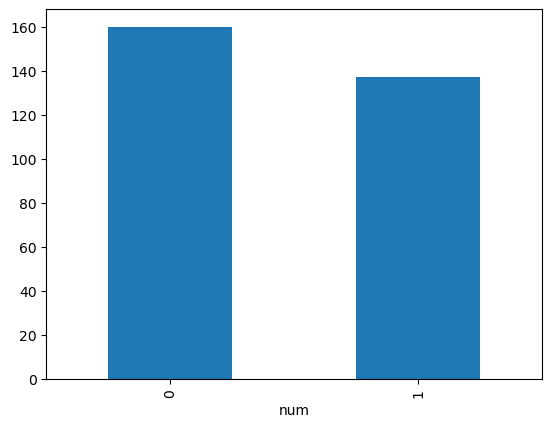

In [7]:
df['num'].value_counts().sort_index().plot(kind='bar')

In [8]:
100 * df['num'].value_counts()/df.shape[0]

num
0    53.872054
1    46.127946
Name: count, dtype: float64

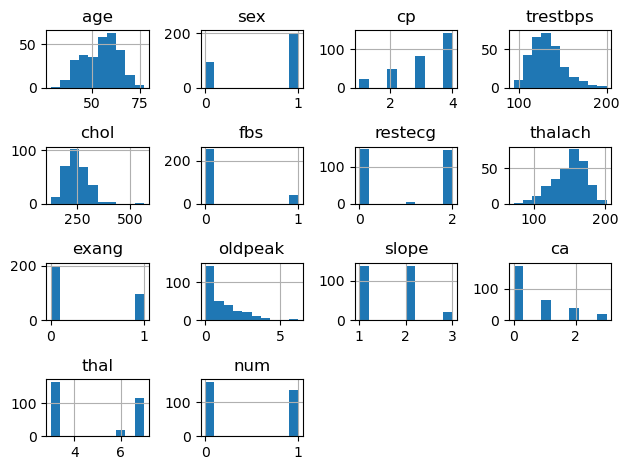

In [9]:
df.hist()
plt.tight_layout ()

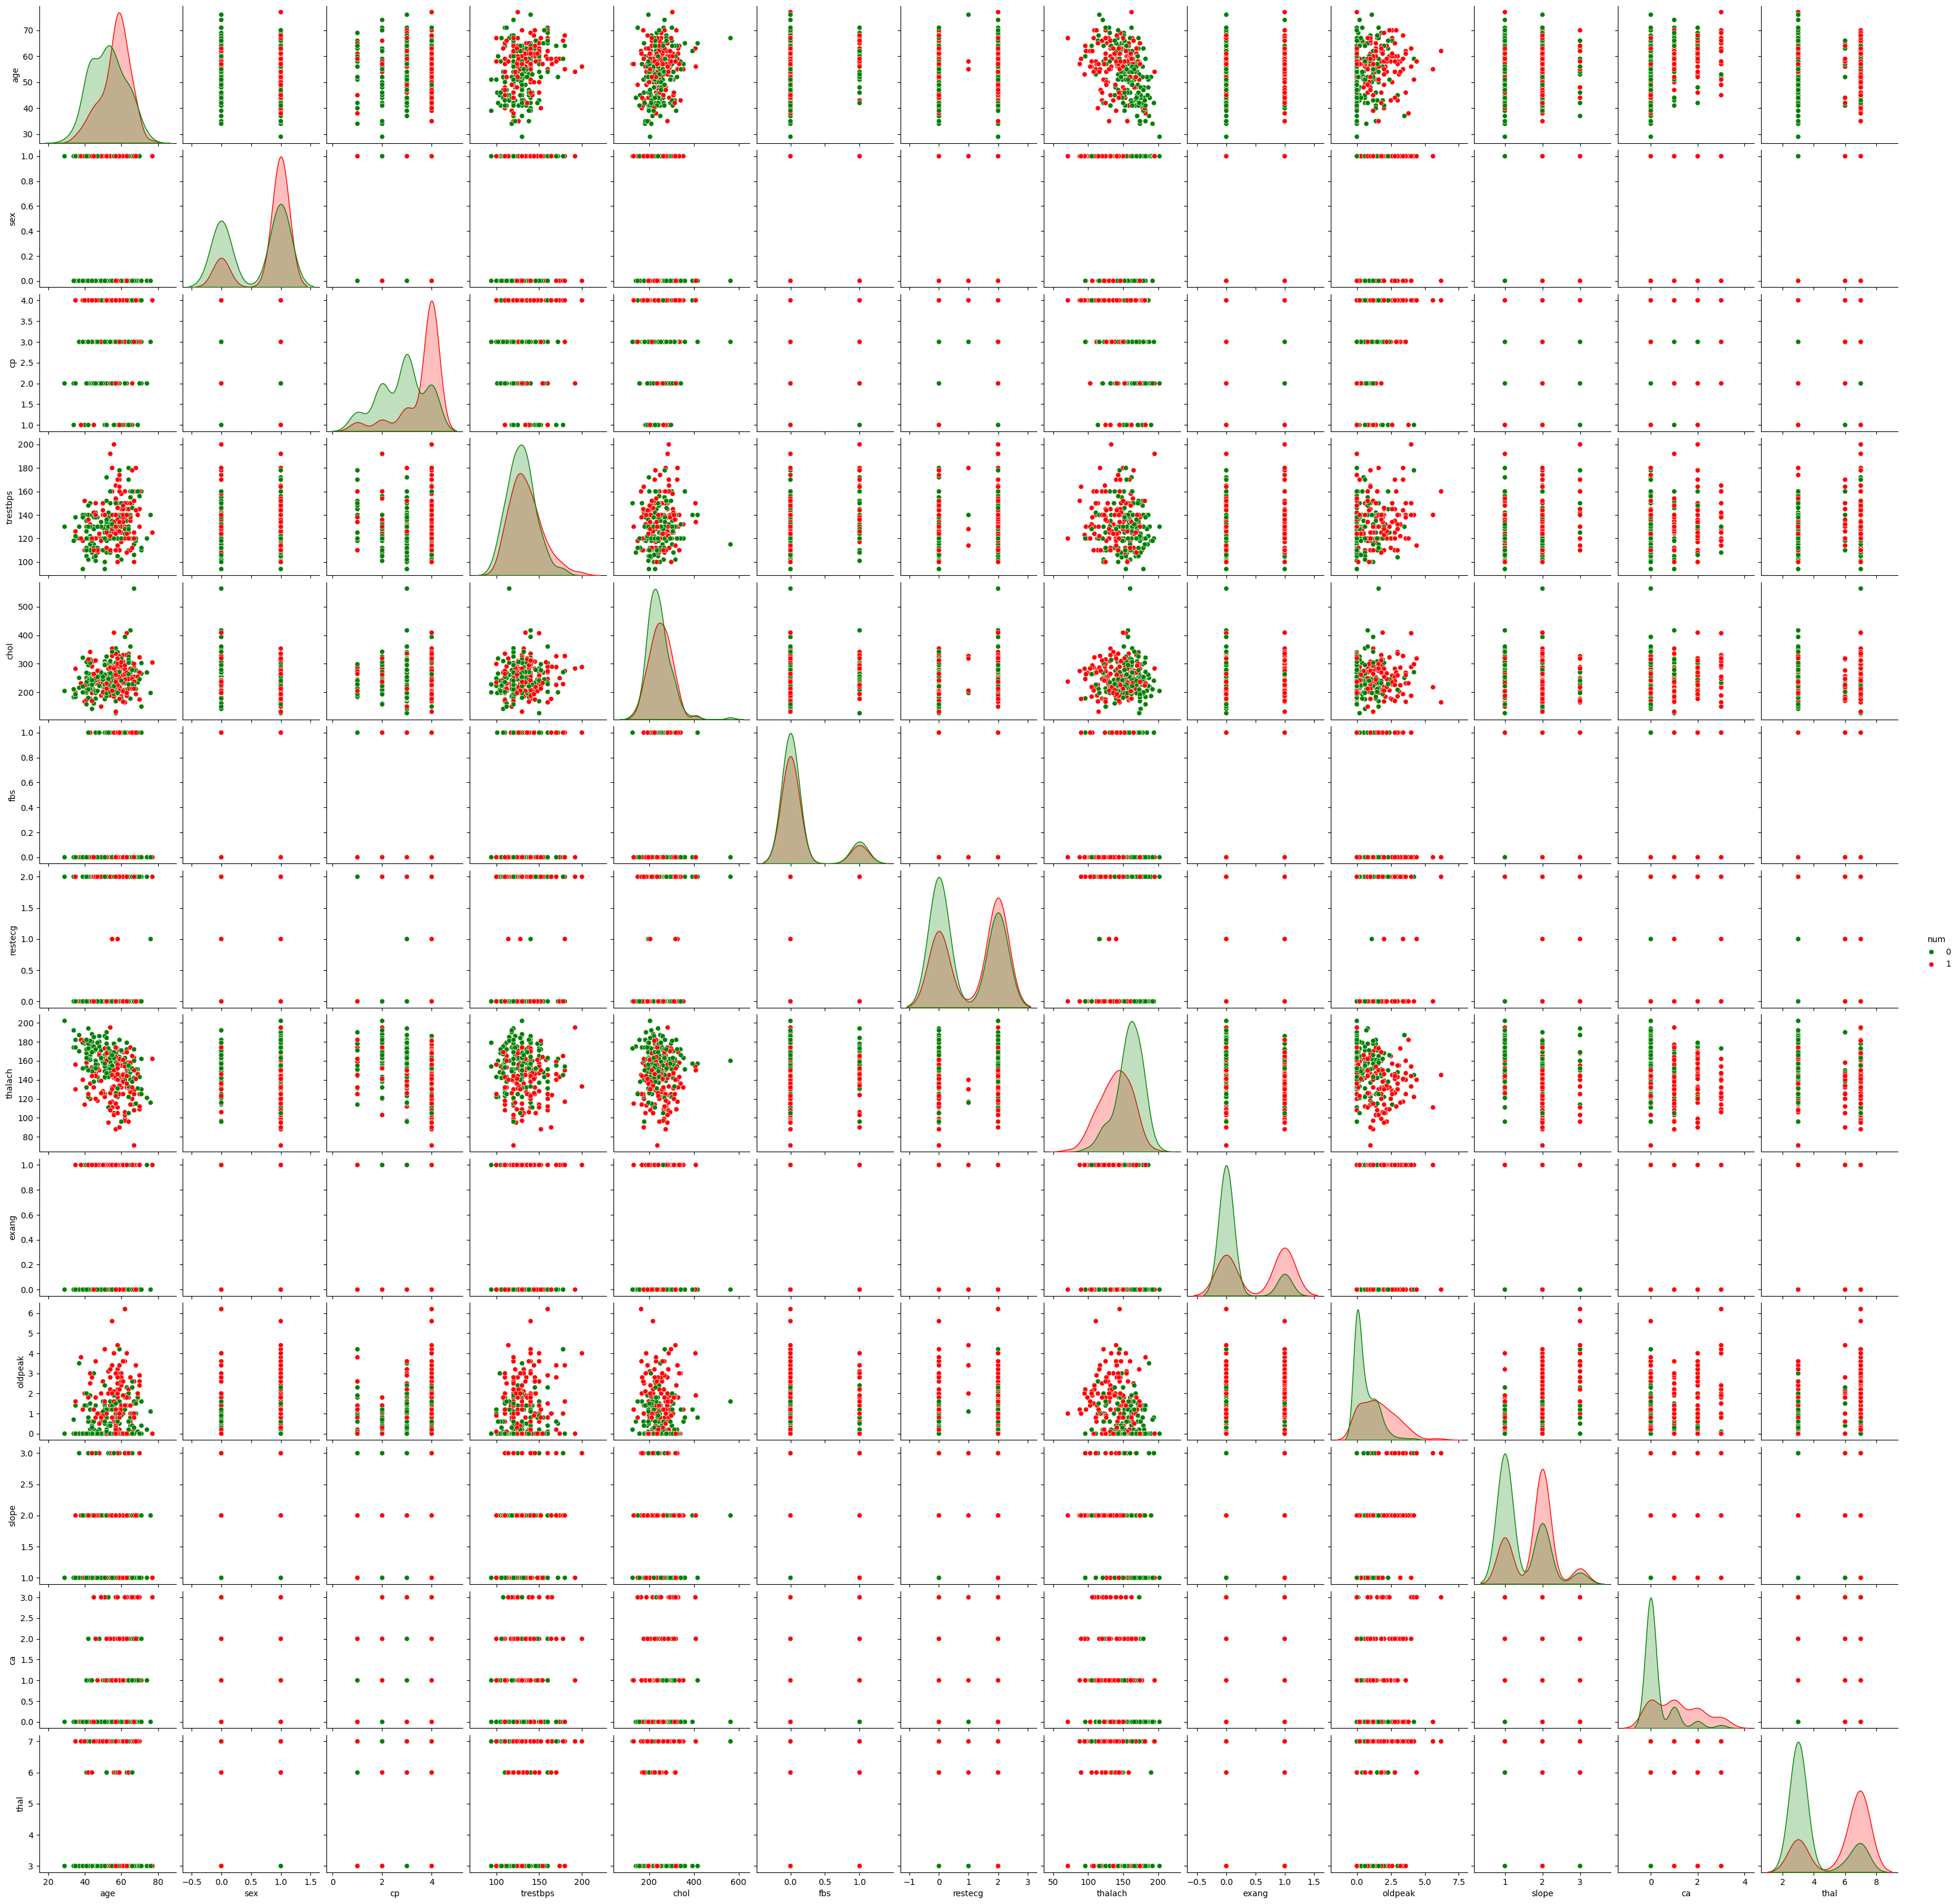

In [10]:
sns.pairplot(data=df, hue='num', palette={0:'green', 1:'red'})